In [1]:
#!/usr/bin/env python3

import os
import numpy as np
import pandas as pd
import arviz as az

# --------------------------------------------------
# Config
# --------------------------------------------------
BASE_DATA_DIR = "../data"
FIG_DIR = "../figures/roni_dmi_city_extremes"
os.makedirs(FIG_DIR, exist_ok=True)

TARGET_VARS = ["wbt_daily_peak"]

SCENARIOS = [
    {"name": "El Niño (+1,0)",                 "N": +1.0, "D":  0.0},
    {"name": "La Niña (-1,0)",                 "N": -1.0, "D":  0.0},
    {"name": "pIOD (0,+1)",                    "N":  0.0, "D": +1.0},
    {"name": "nIOD (0,-1)",                    "N":  0.0, "D": -1.0},
    {"name": "La Niña + pIOD (-1,+1)",         "N": -1.0, "D": +1.0},
    {"name": "La Niña + nIOD (-1,-1)",         "N": -1.0, "D": -1.0},
    {"name": "Strong La Niña (-2,0)",          "N": -2.0, "D":  0.0},
    {"name": "Super La Niña (-2.5,0)",         "N": -2.5, "D":  0.0},
    {"name": "Strong La Niña + nIOD (-2,-1)",  "N": -2.0, "D": -1.0},
    {"name": "Strong El Niño (+2,0)",          "N": +2.0, "D":  0.0},
    {"name": "El Niño + pIOD (+1,+1)",         "N": +1.0, "D": +1.0},
    {"name": "El Niño + nIOD (+1,-1)",         "N": +1.0, "D": -1.0},
]

POOLED_SPACE_ORDER = {
    # must match pooled fit order in Bernoulli model script
    "gulf_coastal_pooled": ["doha", "dubai", "dammam"],
}

CITY_ORDER = [
    "muscat",
    "doha",
    "dubai",
    "dammam",
    "kuwait_city",
    "basra",
    "jeddah",
    "aden",
    "medina",
    "riyadh",
]

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def stack_samples(da):
    return da.stack(sample=("chain", "draw")).values

def get_var_paths(var):
    run_dir = os.path.join(BASE_DATA_DIR, f"{var}_daily_city_runs_bernoulli")
    csv_path = os.path.join(run_dir, f"{var}_daily_bernoulli_city_roni_dmi_summary.csv")
    return run_dir, csv_path

def load_idata(run_dir, run_id):
    path = os.path.join(run_dir, f"idata_{run_id}.nc")
    if os.path.exists(path):
        return az.from_netcdf(path), path
    return None, path

# --------------------------------------------------
# Core computation
# --------------------------------------------------
def compute_impacts_for_var(var):
    run_dir, csv_path = get_var_paths(var)

    if not os.path.exists(csv_path):
        print(f"⚠️ missing summary CSV for {var}: {csv_path}")
        return None

    df = pd.read_csv(csv_path)
    rows = []

    for _, r in df.iterrows():
        city = r["city"]
        run_id = r["run_id"]

        # skip pooled hyper row
        if city == "ALL":
            continue

        # --------------------------
        # pooled city rows
        # --------------------------
        if ":" in run_id:
            base_run, city_name = run_id.split(":", 1)
            idata, expected_path = load_idata(run_dir, base_run)
            if idata is None:
                print(f"⚠️ missing pooled idata: {expected_path}")
                continue

            pooled_group = r.get("pooled_group", "")
            lookup_key = None

            if pooled_group in POOLED_SPACE_ORDER:
                lookup_key = pooled_group
            elif base_run in POOLED_SPACE_ORDER:
                lookup_key = base_run
            else:
                for key in POOLED_SPACE_ORDER:
                    if key in str(pooled_group) or key in str(base_run):
                        lookup_key = key
                        break

            if lookup_key is None:
                raise ValueError(
                    f"Unknown pooled space order for pooled_group='{pooled_group}' "
                    f"and base_run='{base_run}'"
                )

            order = POOLED_SPACE_ORDER[lookup_key]
            if city_name not in order:
                raise ValueError(f"City '{city_name}' not found in pooled order {order}")

            s = order.index(city_name)

            post = idata.posterior
            a   = stack_samples(post["a_s"].isel(space=s))
            bN  = stack_samples(post["bN_s"].isel(space=s))
            bD  = stack_samples(post["bD_s"].isel(space=s))
            bND = stack_samples(post["bND_s"].isel(space=s))

        # --------------------------
        # single-city rows
        # --------------------------
        else:
            idata, expected_path = load_idata(run_dir, run_id)
            if idata is None:
                print(f"⚠️ missing single-city idata: {expected_path}")
                continue

            post = idata.posterior
            a   = stack_samples(post["a"])
            bN  = stack_samples(post["bN"])
            bD  = stack_samples(post["bD"])
            bND = stack_samples(post["bND"])

        # baseline exceedance probability
        p0 = logistic(a)

        for scen in SCENARIOS:
            scen_name = scen["name"]
            Nval = scen["N"]
            Dval = scen["D"]
            NDval = Nval * Dval

            eta1 = a + bN * Nval + bD * Dval + bND * NDval
            p1 = logistic(eta1)

            dp = p1 - p0                 # absolute probability change
            rr = p1 / p0                # risk ratio
            oratio = np.exp(bN * Nval + bD * Dval + bND * NDval)  # odds ratio

            dp_lo, dp_hi = az.hdi(dp, hdi_prob=0.94)
            p1_lo, p1_hi = az.hdi(p1, hdi_prob=0.94)
            rr_lo, rr_hi = az.hdi(rr, hdi_prob=0.94)
            or_lo, or_hi = az.hdi(oratio, hdi_prob=0.94)
            p0_lo, p0_hi = az.hdi(p0, hdi_prob=0.94)

            rows.append({
                "var": var,
                "city": city,
                "run_id": run_id,
                "scenario": scen_name,
                "delta_p_mean": float(dp.mean()),
                "delta_p_hdi_low": float(dp_lo),
                "delta_p_hdi_high": float(dp_hi),
                "p_base_mean": float(p0.mean()),
                "p_base_hdi_low": float(p0_lo),
                "p_base_hdi_high": float(p0_hi),
                "p_scen_mean": float(p1.mean()),
                "p_scen_hdi_low": float(p1_lo),
                "p_scen_hdi_high": float(p1_hi),
                "risk_ratio_mean": float(rr.mean()),
                "risk_ratio_hdi_low": float(rr_lo),
                "risk_ratio_hdi_high": float(rr_hi),
                "odds_ratio_mean": float(oratio.mean()),
                "odds_ratio_hdi_low": float(or_lo),
                "odds_ratio_hdi_high": float(or_hi),
                "N": Nval,
                "D": Dval,
            })

    if not rows:
        return None

    out_df = pd.DataFrame(rows)
    out_df["city"] = pd.Categorical(out_df["city"], categories=CITY_ORDER, ordered=True)
    out_df = out_df.sort_values(["city", "scenario"]).reset_index(drop=True)

    out_csv = os.path.join(run_dir, f"{var}_bernoulli_scenario_impacts.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"✅ wrote: {out_csv}")

    return out_df

# --------------------------------------------------
# Main
# --------------------------------------------------
def main():
    for var in TARGET_VARS:
        print(f"\n=== Processing {var} ===")
        compute_impacts_for_var(var)

if __name__ == "__main__":
    main()



=== Processing wbt_daily_peak ===


ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


✅ wrote: ../data/wbt_daily_peak_daily_city_runs_bernoulli/wbt_daily_peak_bernoulli_scenario_impacts.csv


Saved PNG: ../figures/city_roni_dmi_bernoulli/wbt_daily_peak_bernoulli_probability_change_bigpanel.png
Saved PDF: ../figures/city_roni_dmi_bernoulli/wbt_daily_peak_bernoulli_probability_change_bigpanel_manuscript.pdf


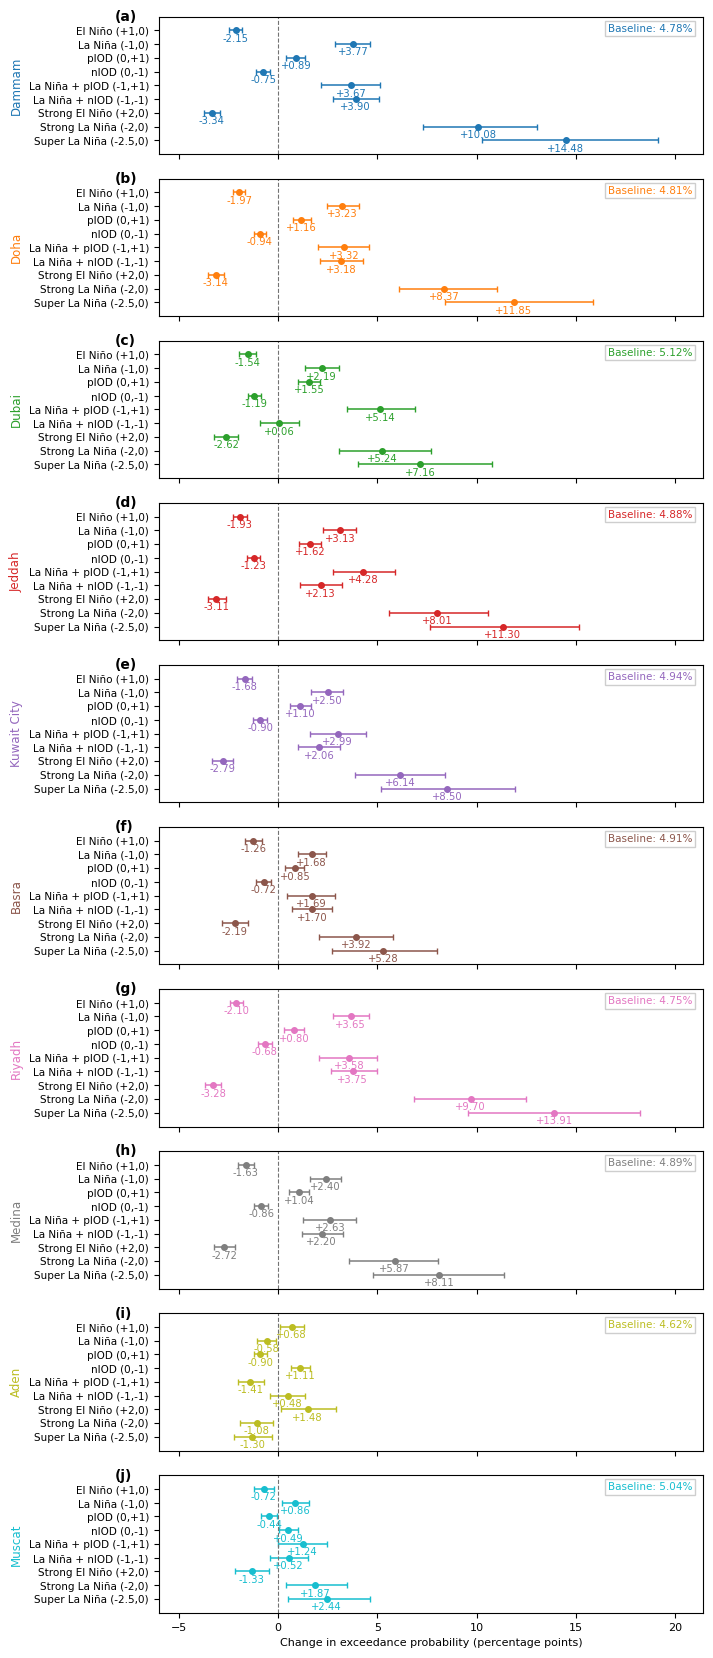

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# --------------------------------------------------
# ERL manuscript style
# --------------------------------------------------
ERL_RC = {
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.transparent": False,
    "path.simplify": False,
}
mpl.rcParams.update(ERL_RC)

# --------------------------------------------------
# Paths
# --------------------------------------------------
BASE_DATA = "../data"
FIG_DIR = "../figures/city_roni_dmi_bernoulli"
os.makedirs(FIG_DIR, exist_ok=True)

# --------------------------------------------------
# Config
# --------------------------------------------------
TARGET_VARS = ["wbt_daily_peak"]

SCENARIOS_TO_PLOT = [
    "El Niño (+1,0)",
    "La Niña (-1,0)",
    "pIOD (0,+1)",
    "nIOD (0,-1)",
    "La Niña + pIOD (-1,+1)",
    "La Niña + nIOD (-1,-1)",
    "Strong El Niño (+2,0)",
    "Strong La Niña (-2,0)",
    "Super La Niña (-2.5,0)",
]

CITY_ORDER = [
    "dammam",
    "doha",
    "dubai",
    "jeddah",
    "kuwait_city",
    "basra",
    "riyadh",
    "medina",
    "aden",
    "muscat",
]

CITY_LABELS = {
    "muscat": "Muscat",
    "doha": "Doha",
    "dubai": "Dubai",
    "dammam": "Dammam",
    "kuwait_city": "Kuwait City",
    "basra": "Basra",
    "jeddah": "Jeddah",
    "aden": "Aden",
    "medina": "Medina",
    "riyadh": "Riyadh",
}

VAR_LABELS = {
    "wbt_daily_peak": "Wet-Bulb Temperature exceedance probability",
}

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def pretty_city(city: str) -> str:
    return CITY_LABELS.get(city, city.replace("_", " ").title())

def compute_global_xlim(df, scenarios_to_plot):
    sub = df[df["scenario"].isin(scenarios_to_plot)].copy()
    if sub.empty:
        return (-5, 5)

    # convert to percentage points
    xmin = np.nanmin(100.0 * sub["delta_p_hdi_low"].values)
    xmax = np.nanmax(100.0 * sub["delta_p_hdi_high"].values)

    if not np.isfinite(xmin) or not np.isfinite(xmax):
        return (-5, 5)

    span = xmax - xmin
    pad = 0.10 * span if span > 0 else 1.0
    return xmin - pad, xmax + pad

# --------------------------------------------------
# Main plotting
# --------------------------------------------------
for var in TARGET_VARS:
    csv_path = f"{BASE_DATA}/{var}_daily_city_runs_bernoulli/{var}_bernoulli_scenario_impacts.csv"

    if not os.path.exists(csv_path):
        print("Missing:", csv_path)
        continue

    impact_df = pd.read_csv(csv_path)
    impact_df = impact_df[impact_df["scenario"].isin(SCENARIOS_TO_PLOT)].copy()

    if impact_df.empty:
        print(f"No matching scenarios found for {var}")
        continue

    cities_present = impact_df["city"].dropna().unique().tolist()
    cities = [c for c in CITY_ORDER if c in cities_present]

    if not cities:
        print(f"No matching cities found for {var}")
        continue

    xlim = compute_global_xlim(impact_df, SCENARIOS_TO_PLOT)

    nrows = len(cities)
    fig_height = max(1.6 * nrows + 0.7, 8.0)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=1,
        figsize=(7.2, fig_height),
        sharex=True,
        sharey=False,
    )

    
    if nrows == 1:
        axes = np.array([axes])

    cmap = plt.get_cmap("tab10")
    city_colors = {city: cmap(i % 10) for i, city in enumerate(cities)}

    y_spacing = 1.4
    y = np.arange(len(SCENARIOS_TO_PLOT)) * y_spacing

    for i, city in enumerate(cities):
        ax = axes[i]
        label = f"({chr(97 + i)})"  # 97 = 'a'

        ax.text(
            -0.08, 1.05, label,
            transform=ax.transAxes,
            fontsize=10,
            fontweight="bold",
            va="top",
            ha="left"
        )
        dfc = impact_df[impact_df["city"] == city].copy()
        city_color = city_colors[city]

        sub = (
            dfc.set_index("scenario")
            .reindex(SCENARIOS_TO_PLOT)
        )

        mean = 100.0 * sub["delta_p_mean"].values
        lo = 100.0 * sub["delta_p_hdi_low"].values
        hi = 100.0 * sub["delta_p_hdi_high"].values

        ax.errorbar(
            mean,
            y,
            xerr=[mean - lo, hi - mean],
            fmt="o",
            capsize=2.5,
            linewidth=1.1,
            color=city_color,
            ecolor=city_color,
            markersize=4.0,
        )

        ax.axvline(0, linestyle="--", linewidth=0.8, color="0.45")

        # annotate each point with the posterior mean in percentage points
        dy = 0.22 * y_spacing
        for k, m in enumerate(mean):
            if np.isfinite(m):
                ax.text(
                    m,
                    y[k] + dy,
                    f"{m:+.2f}",
                    ha="center",
                    va="top",
                    fontsize=7.2,
                    color=city_color,
                )

        # baseline exceedance probability
        p0 = 100.0 * float(np.nanmean(sub["p_base_mean"].values))
        ax.text(
            0.98, 0.95,
            f"Baseline: {p0:.2f}%",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=7.5,
            color=city_color,
            bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.95, pad=2.0),
        )

        ax.set_xlim(xlim)
        ax.set_yticks(y)
        ax.set_yticklabels(SCENARIOS_TO_PLOT, fontsize=7.5)
        ax.set_ylabel(pretty_city(city), fontsize=8.5, color=city_color)
        ax.set_ylim(y[-1] + 1.0 * y_spacing, -1.0 * y_spacing)

        if i == nrows - 1:
            ax.set_xlabel("Change in exceedance probability (percentage points)", fontsize=8)

    # -------------------------------
    # Save PNG WITH title
    # -------------------------------
    st = fig.suptitle(
        f"{VAR_LABELS.get(var, var)} response to ENSO / IOD scenarios",
        fontsize=10,
        y=0.995,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.985])

    png_out = f"{FIG_DIR}/{var}_bernoulli_probability_change_bigpanel.png"
    fig.savefig(png_out, dpi=300, bbox_inches="tight")
    print("Saved PNG:", png_out)

    # -------------------------------
    # Save PDF WITHOUT title
    # -------------------------------
    st.remove()
    fig.subplots_adjust(top=0.985)

    pdf_out = f"{FIG_DIR}/{var}_bernoulli_probability_change_bigpanel_manuscript.pdf"
    fig.savefig(pdf_out)
    print("Saved PDF:", pdf_out)

    plt.show()
    plt.close()
